In [2]:
import PyMieScatt as ps

ps.MieQ(1.77+0.63j,375,300,asDict=True)

{'Qext': 2.8584971991564117,
 'Qsca': 1.3149276685170945,
 'Qabs': 1.5435695306393171,
 'g': 0.7251162362148785,
 'Qpr': 1.9050217972664907,
 'Qback': 0.2014551048135256,
 'Qratio': 0.15320622543498225}

In [3]:
ps.__version__

'1.7.5.4'

In [23]:
m = 1.77+0.63j
wavelength = 375
diameter = 300
ps.MatrixElements(m, wavelength, diameter, 0)

(0.2879901152047223,
 0.025191830991689118,
 (-0.12552989767452222+0j),
 (-0.2579649644752934+0j))

In [20]:
import numpy as np
S1, S2 = ps.MieS1S2(m, np.pi*diameter/wavelength, 0)
(0.5*(abs(S2)**2 + abs(S1)**2), 0.5*(abs(S2)**2 + abs(S1)**2), 0.5*(np.conj(S2)*S1+np.conj(S1)*S2), 0.5j*(np.conj(S2)*S1-np.conj(S1)*S2))

(0.2879901152047223,
 0.2879901152047223,
 (-0.12552989767452222+0j),
 (-0.2579649644752934+0j))

In [3]:
import PyMieScatt as ps
import numpy as np
import matplotlib.pyplot as plt
dp = np.linspace(10,1000,1000)
N,sh,sc = 1e5,5,200
w=[N*((sh/sc)*(d/sc)**(sh-1))*np.exp(-(d/sc)**sh) for d in dp]
ps.Mie_SD(1.5+0.5j,405,dp,w,asDict=True,SMPS=False)

{'Bext': 5747.446650209562,
 'Bsca': 1985.3986899482204,
 'Babs': 3762.0479602613414,
 'G': 0.5466232557873612,
 'Bpr': 4662.181554274104,
 'Bback': 286.6569899998168,
 'Bratio': 550.8716311163472}

C:\Users\zhaofei\AppData\Local\Temp\ipykernel_50844\3071431264.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


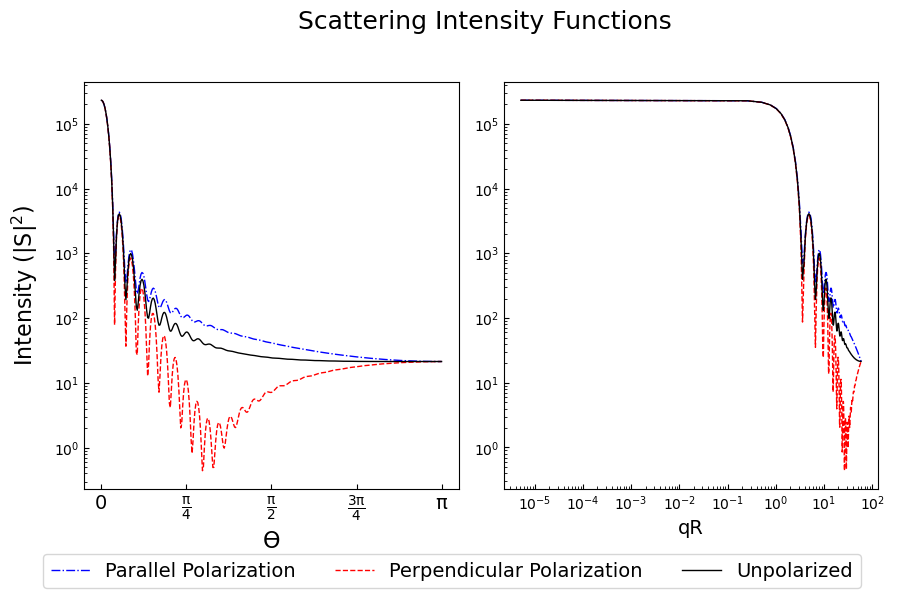

In [4]:
import PyMieScatt as ps
import numpy as np
import matplotlib.pyplot as plt

m=1.7+0.5j
w=532
d=5000

theta,SL,SR,SU = ps.ScatteringFunction(m,w,d)
qR,SLQ,SRQ,SUQ = ps.ScatteringFunction(m,w,d,space='qspace')

plt.close('all')

fig1 = plt.figure(figsize=(10,6))
ax1 = fig1.add_subplot(1,2,1)
ax2 = fig1.add_subplot(1,2,2)

ax1.semilogy(theta,SL,'b',ls='dashdot',lw=1,label="Parallel Polarization")
ax1.semilogy(theta,SR,'r',ls='dashed',lw=1,label="Perpendicular Polarization")
ax1.semilogy(theta,SU,'k',lw=1,label="Unpolarized")

x_label = ["0", r"$\mathregular{\frac{\pi}{4}}$", r"$\mathregular{\frac{\pi}{2}}$",r"$\mathregular{\frac{3\pi}{4}}$",r"$\mathregular{\pi}$"]
x_tick = [0,np.pi/4,np.pi/2,3*np.pi/4,np.pi]
ax1.set_xticks(x_tick)
ax1.set_xticklabels(x_label,fontsize=14)
ax1.tick_params(which='both',direction='in')
ax1.set_xlabel("ϴ",fontsize=16)
ax1.set_ylabel(r"Intensity ($\mathregular{|S|^2}$)",fontsize=16,labelpad=10)

ax2.loglog(qR,SLQ,'b',ls='dashdot',lw=1,label="Parallel Polarization")
ax2.loglog(qR,SRQ,'r',ls='dashed',lw=1,label="Perpendicular Polarization")
ax2.loglog(qR,SUQ,'k',lw=1,label="Unpolarized")

ax2.tick_params(which='both',direction='in')
ax2.set_xlabel("qR",fontsize=14)
handles, labels = ax1.get_legend_handles_labels()
fig1.legend(handles,labels,fontsize=14,ncol=3,loc=8)

fig1.suptitle("Scattering Intensity Functions",fontsize=18)
fig1.show()
plt.tight_layout(rect=[0.01,0.05,0.915,0.95])